## 1. La legge dei grandi numeri

La legge dei grandi numeri è un teorema fondamentale della teoria della probabilità che indica che se ripetiamo molte volte (tendendo all'infinito) lo stesso esperimento, la frequenza di un certo evento tende ad essere costante.

Vale a dire, **la legge dei grandi numeri indica che se lo stesso test viene eseguito ripetutamente (ad esempio, lancio di una moneta), la frequenza con cui si ripeterà un determinato evento (testa/croce) si avvicinerà a una costante. Questa a sua volta sarà la probabilità che questo evento si verifichi.**

Fonte: https://it.economy-pedia.com/11038376-law-of-the-big-numbers

- Scrivere una funzione che simula il lancio di una moneta per N volte e restituisce la frequenza % di volte che è uscita testa.
- Calcolare la frequenza % con la grandezze del campione (numero di lanci) che varia 100 volte da 10 a 20000. Ottengo quindi 100 valori.
- Fare il plot del Numero medio di teste (y) rispetto alla grandezza del campione (x)





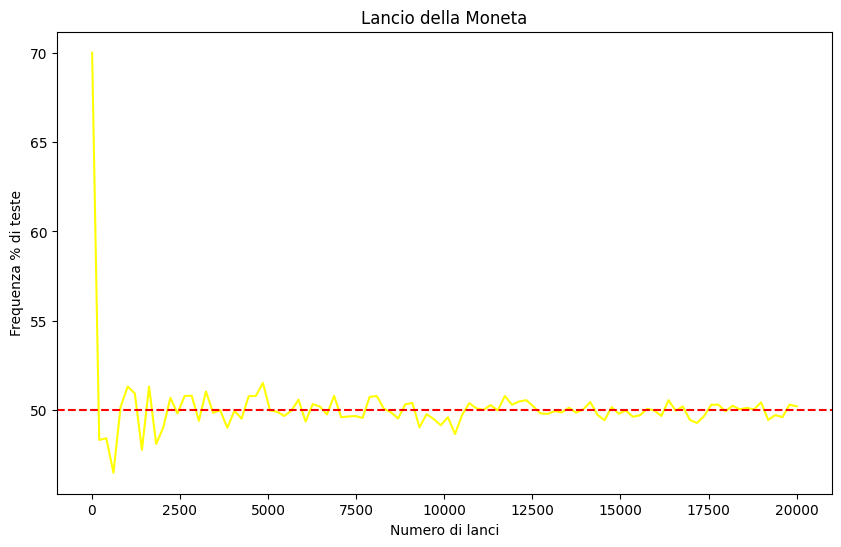

In [58]:
import numpy as np
import matplotlib.pyplot as plt

# 1.funzione che simula il lancio della moneta
def simula_lanci(n_lanci):
    #numeri casuali tra 0 e 1 (0 = croce, 1 = testa)
    lanci = np.random.randint(0, 2, n_lanci)
    
    # Contiamo quante volte è uscito testa
    teste = np.sum(lanci == 1)
    # Calcolo frequenza percentuale
    frequenza = (teste / n_lanci) * 100
    return frequenza

# 2.calcolo della frequenza con campione variabile
campioni = np.linspace(10, 20000, 100, dtype=int) 
frequenze = []
for n in campioni:
    frequenze.append(simula_lanci(n)) 

# 3.plot
plt.figure(figsize=(10, 6))
plt.plot(campioni, frequenze, color='yellow')
plt.axhline(y=50, color='red', linestyle='--')

#Grafico
plt.title('Lancio della Moneta')
plt.xlabel('Numero di lanci')
plt.ylabel('Frequenza % di teste')

plt.show()

## 2. Analisi del Dataset Titanic
- Quante righe e colonne ha il dataset?
- Controlla quanti valori mancanti ci sono per colonna
- Riempi i valori mancanti nella colonna 'Embarked' con il valore più frequente
- Controlla se ci sono righe duplicate
- Calcola l'età media dei passeggeri per ogni classe (`Pclass`), se ci sono valori mancanti di età nella colonna 'Age' riempili con il valore medio
- Visualizza la distribuzione dell'età per classe
- Visualizza la distribuzione dell'età per classe dividendo e mostrando insieme i dati di uomini e donne

In [ ]:
# Caricamento del dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [66]:
#quante righe e colonne ha il dataset?
df.shape


(891, 12)

In [67]:
#controlla quanti valori mancanti ci sono per colonna
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [72]:

#riempi i valori mancanti nella colonna 'Embarked' con il valore più frequente
most_common = df['Embarked'].mode()[0] 
df['Embarked'].fillna(most_common)
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [73]:
#controllo se ci sono righe duplicate
df.duplicated().sum()

np.int64(0)

In [ ]:
#Calcola l'età media dei passeggeri per ogni classe (`Pclass`), se ci sono valori mancanti di età nella colonna 'Age' riempili con il valore medio
media_anni = df['Age'].mean()
df['Age'].fillna(media_anni)

df.groupby('Pclass')['Age'].mean()

Pclass
1    38.233441
2    29.877630
3    25.140620
Name: Age, dtype: float64

<Axes: xlabel='Pclass', ylabel='Age'>

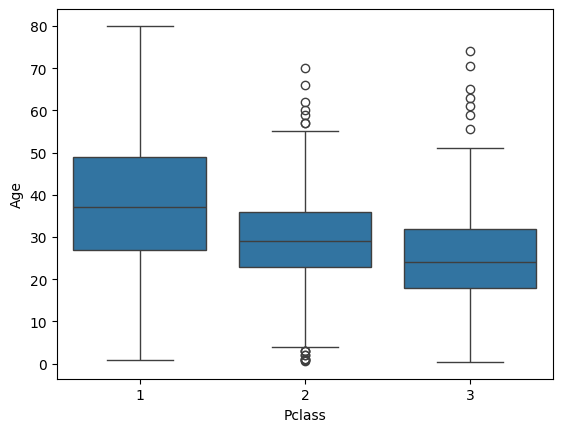

In [83]:
#Visualizza la distribuzione dell'età per classe
sns.boxplot(x='Pclass', y='Age', data=df)

<Axes: xlabel='Pclass', ylabel='Age'>

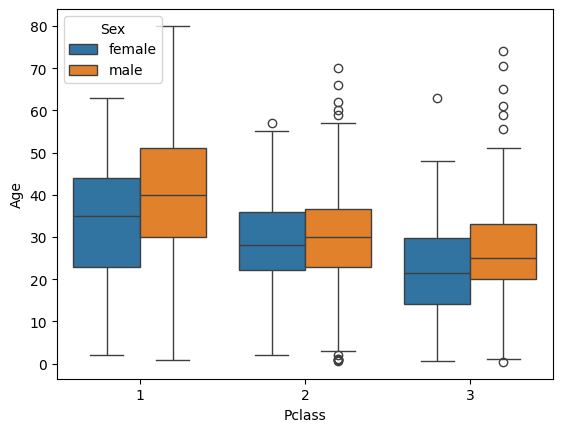

In [87]:
#Visualizza la distribuzione dell'età per classe dividendo e mostrando insieme i dati di uomini e donne
sns.boxplot(data=df, x='Pclass', y='Age', hue = 'Sex')

## 3. Analisi del Dataset Iris

- Esplora la distribuzione delle specie (conta quanti campioni ci sono per specie)
- Calcola la lunghezza e la larghezza media dei petali per specie
- Visualizza le dimensioni dei petali per specie (scatterplot)
- Crea una nuova colonna per l'area del petalo e analizzala
- Grafico della distribuzione dell'area del petalo per specie (boxplot)

Quanti fiori ci sono per ogni specie?
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

In media, quanto sono grandi i petali?
            petal_length  petal_width
species                              
setosa             1.462        0.246
versicolor         4.260        1.326
virginica          5.552        2.026


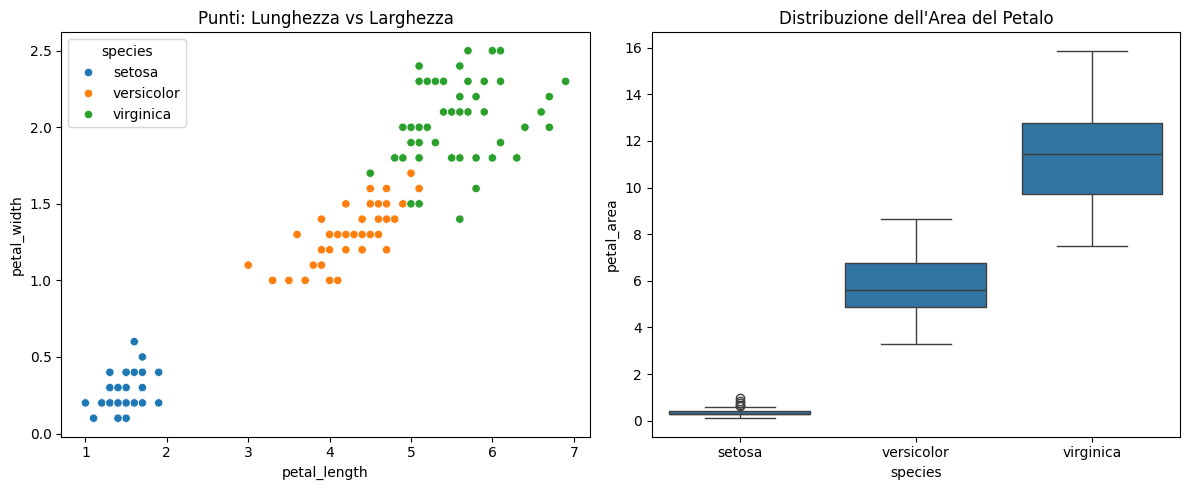

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"
df = pd.read_csv(url)

# Quanti fiori ci sono per ogni tipo?
# Usiamo value_counts() per contare le specie
print("Quanti fiori ci sono per ogni specie?")
print(df['species'].value_counts())

# Qual è la media dei petali? 
medie = df.groupby('species')[['petal_length', 'petal_width']].mean()
print("\nIn media, quanto sono grandi i petali?")
print(medie)

# Colonna per l'Area
df['petal_area'] = df['petal_length'] * df['petal_width']

# GRAFICI
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # Metti questo grafico a sinistra
sns.scatterplot(data=df, x='petal_length', y='petal_width', hue='species')
plt.title('Punti: Lunghezza vs Larghezza')

plt.subplot(1, 2, 2) 
sns.boxplot(data=df, x='species', y='petal_area')
plt.title('Distribuzione dell\'Area del Petalo')

plt.tight_layout()
plt.show()